In [107]:
import sys
import os
import pandas as pd
import importlib

# Proje kök dizinini Python arama yolunda en üste al
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Proje kök dizinini arama yolunun en üstüne ekleyelim

# utils.py içindeki fonksiyonları import edelim
import src.utils as utils
importlib.reload(utils) # utils modülünü yeniden yükleyelim, böylece yapılan değişiklikler geçerli olur
chronogical_split = utils.chronogical_split

# EDA aşamasındaki veriyi yükleyelim
data_path = '../data/processed/nrel_data_5cities_filtered.parquet'
print(f"Veri dosyası: {data_path}...")
df = pd.read_parquet(data_path)
print(f"Veri başarıyla yüklendi. Toplam kayıt sayısı: {len(df)}")

# Kronolojik olarak veriyi bölerek eğitim ve test setlerini oluşturalım
train_df, val_df, test_df = chronogical_split(df, datetime_col ='datetime')

# 4. TEST VE SAĞLAMALAR (Hata yapıp yapmadığımızı buradan göreceğiz)
print("\n--- Veri Bölünme Raporu ---")
print(f"Eğitim Seti (Train) : {len(train_df):,} satır | Başlangıç: {train_df.index.min()} | Bitiş: {train_df.index.max()}")
print(f"Doğrulama Seti (Val): {len(val_df):,} satır  | Başlangıç: {val_df.index.min()} | Bitiş: {val_df.index.max()}")
print(f"Test Seti (Test)    : {len(test_df):,} satır  | Başlangıç: {test_df.index.min()} | Bitiş: {test_df.index.max()}")

# Şehir bazında dağılım kontrolü
print("\n--- Eğitim Setindeki Şehir Dağılımı ---")
print(train_df['City'].value_counts())

Veri dosyası: ../data/processed/nrel_data_5cities_filtered.parquet...
Veri başarıyla yüklendi. Toplam kayıt sayısı: 221516

--- Veri Bölünme Raporu ---
Eğitim Seti (Train) : 132,912 satır | Başlangıç: 0 | Bitiş: 132911
Doğrulama Seti (Val): 44,312 satır  | Başlangıç: 0 | Bitiş: 44311
Test Seti (Test)    : 44,292 satır  | Başlangıç: 0 | Bitiş: 44291

--- Eğitim Setindeki Şehir Dağılımı ---
City
Seattle_WA    26743
Boston_MA     26601
Phoenix_AZ    26567
Denver_CO     26555
Miami_FL      26446
Name: count, dtype: int64


In [108]:
import src.utils as utils
importlib.reload(utils) # utils.py içindeki yeni fonksiyonu algılasın

# Modelin kullanacağı özellikleri ve hedefi belirleyelim
TARGET_COL = 'GHI_Filtered' # Hedef değişkenimiz GHI_Filtered olacak
FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 
    'Relative Humidity', 'Wind Speed', 'Cloud Type', 
    'Clearness_Index', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# 96 adım geçmişine bak (48 saat), 24 adım geleceği tahmin et (12 saat)
LOOK_BACK = 96
LOOK_FORWARD = 24

print("1. Eğitim (Train) seti hazırlanıyor...")
X_train, y_train = utils.create_sliding_features(train_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Train seti hazırlandı. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("\n2. Doğrulama (Validation) seti hazırlanıyor...")
X_val, y_val = utils.create_sliding_features(val_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Validation seti hazırlandı. X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print("\n3. Test seti hazırlanıyor...")
X_test, y_test = utils.create_sliding_features(test_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Test seti hazırlandı. X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

1. Eğitim (Train) seti hazırlanıyor...
Train seti hazırlandı. X_train shape: (132317, 96, 11), y_train shape: (132317, 24)

2. Doğrulama (Validation) seti hazırlanıyor...
Validation seti hazırlandı. X_val shape: (43717, 96, 11), y_val shape: (43717, 24)

3. Test seti hazırlanıyor...
Test seti hazırlandı. X_test shape: (43697, 96, 11), y_test shape: (43697, 24)


In [109]:
import torch
from torch.utils.data import TensorDataset, DataLoader

print("\n--- Numpy Dizisinden Tensörler oluşturuluyor ---")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Batch size yani tanımlayalım
BATCH_SIZE = 128

print("\n--- DataLoader'lar oluşturuluyor ---")
# Eğitim seti için Shuffle = True yaparak veriyi karıştıralım ki ezberlemeyi önleyelim
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Doğrulama ve test setleri için Shuffle = False yaparak sıralı kalmasını sağlayalım
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_loader)} batch")
print(f"Validation DataLoader: {len(val_loader)} batch")
print(f"Test DataLoader: {len(test_loader)} batch")


--- Numpy Dizisinden Tensörler oluşturuluyor ---

--- DataLoader'lar oluşturuluyor ---
Train DataLoader: 1034 batch
Validation DataLoader: 342 batch
Test DataLoader: 342 batch


# AutoFormer Grafikleri

Model eğitimi için cihaz: MPS
1. Model Yükleniyor...
1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...
2. Metrikler Hesaplanıyor...

 TEST SETİ KARNESİ AutoFormer (2024)
---------------------------------
RMSE (Kök Ortalama Kare Hata) : 171.9299003227769 
MAE  (Ortalama Mutlak Hata)   : 134.73057556152344 
MSE  (Ortalama Kare Hata)     : 29559.890625 

3. Örnek Bir Zaman Dilimi Çizdiriliyor...


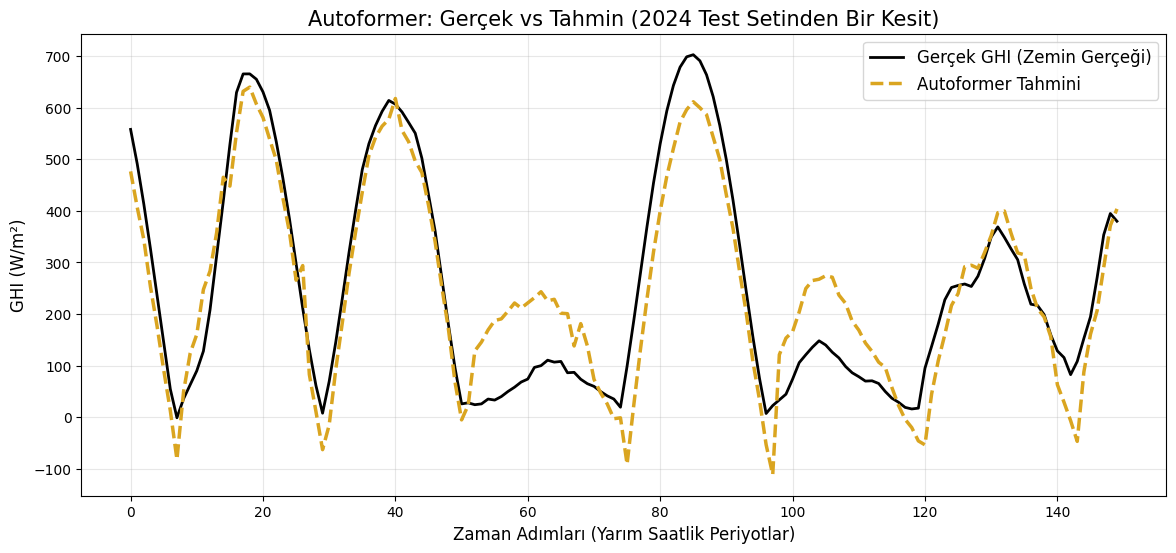

In [110]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")

print("1. Model Yükleniyor...")
# Boş modeli oluştur
model_autoformer = CustomAutoFormer(seq_len=96, pred_len=24, enc_in=11).to(device)
# State dictionary'yi yükle
model_autoformer.load_state_dict(torch.load('../outputs/models/autoformer_solar_model.pth'))

print("1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...")
model_autoformer.eval() # Modeli sınav moduna al (dropout vs kapatılır)

all_predictions = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Tahmin yap
        outputs = model_autoformer(batch_X)
        
        # CPU'ya çek ve numpy array'e çevir
        all_predictions.append(outputs.cpu().numpy())
        all_trues.append(batch_y.cpu().numpy())

# Bütün batch'leri tek bir uzun listeye birleştir
all_predictions = np.concatenate(all_predictions, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print("2. Metrikler Hesaplanıyor...")
# Sadece ilk tahmin adımını (t+1) değil, tüm 24 adımlık (12 saat) ufku değerlendiriyoruz
mse = mean_squared_error(all_trues, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_trues, all_predictions)

print(f"\n TEST SETİ KARNESİ AutoFormer (2024)")
print(f"---------------------------------")
print(f"RMSE (Kök Ortalama Kare Hata) : {rmse} ")
print(f"MAE  (Ortalama Mutlak Hata)   : {mae} ")
print(f"MSE  (Ortalama Kare Hata)     : {mse} ")

# ==========================================
# 3. GÖRSELLEŞTİRME (Gerçek Hava vs Model)
# ==========================================
print("\n3. Örnek Bir Zaman Dilimi Çizdiriliyor...")

START_IDX = 1000
WINDOW_SIZE = 150

# Tahminlerin sadece ilk ufuk adımını (t+1) alarak sürekli bir çizgi oluşturalım
true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, 0]
pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, 0]

plt.figure(figsize=(14, 6))
plt.plot(true_line, label='Gerçek GHI (Zemin Gerçeği)', color='black', linewidth=2)
plt.plot(pred_line, label='Autoformer Tahmini', color='#DAA520', linewidth=2.5, linestyle='--')

plt.title('Autoformer: Gerçek vs Tahmin (2024 Test Setinden Bir Kesit)', fontsize=15)
plt.xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Çıktıyı kaydet
plt.savefig('../outputs/plots/autoformer_test_predictions.pdf', bbox_inches='tight')
plt.show()


⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...

Hedef: 30 Dakika (t+1) -> RMSE: 72.6774 | MAE: 58.3005 | MSE: 5282.0103 | R²: 0.9356 | r: 0.9673
Hedef: 3 Saat (t+6) -> RMSE: 162.4970 | MAE: 128.0628 | MSE: 26405.2637 | R²: 0.6782 | r: 0.8239
Hedef: 6 Saat (t+12) -> RMSE: 180.0676 | MAE: 143.0667 | MSE: 32424.3340 | R²: 0.6048 | r: 0.7783
Hedef: 12 Saat (t+24) -> RMSE: 193.9028 | MAE: 156.9870 | MSE: 37598.2969 | R²: 0.5415 | r: 0.7373


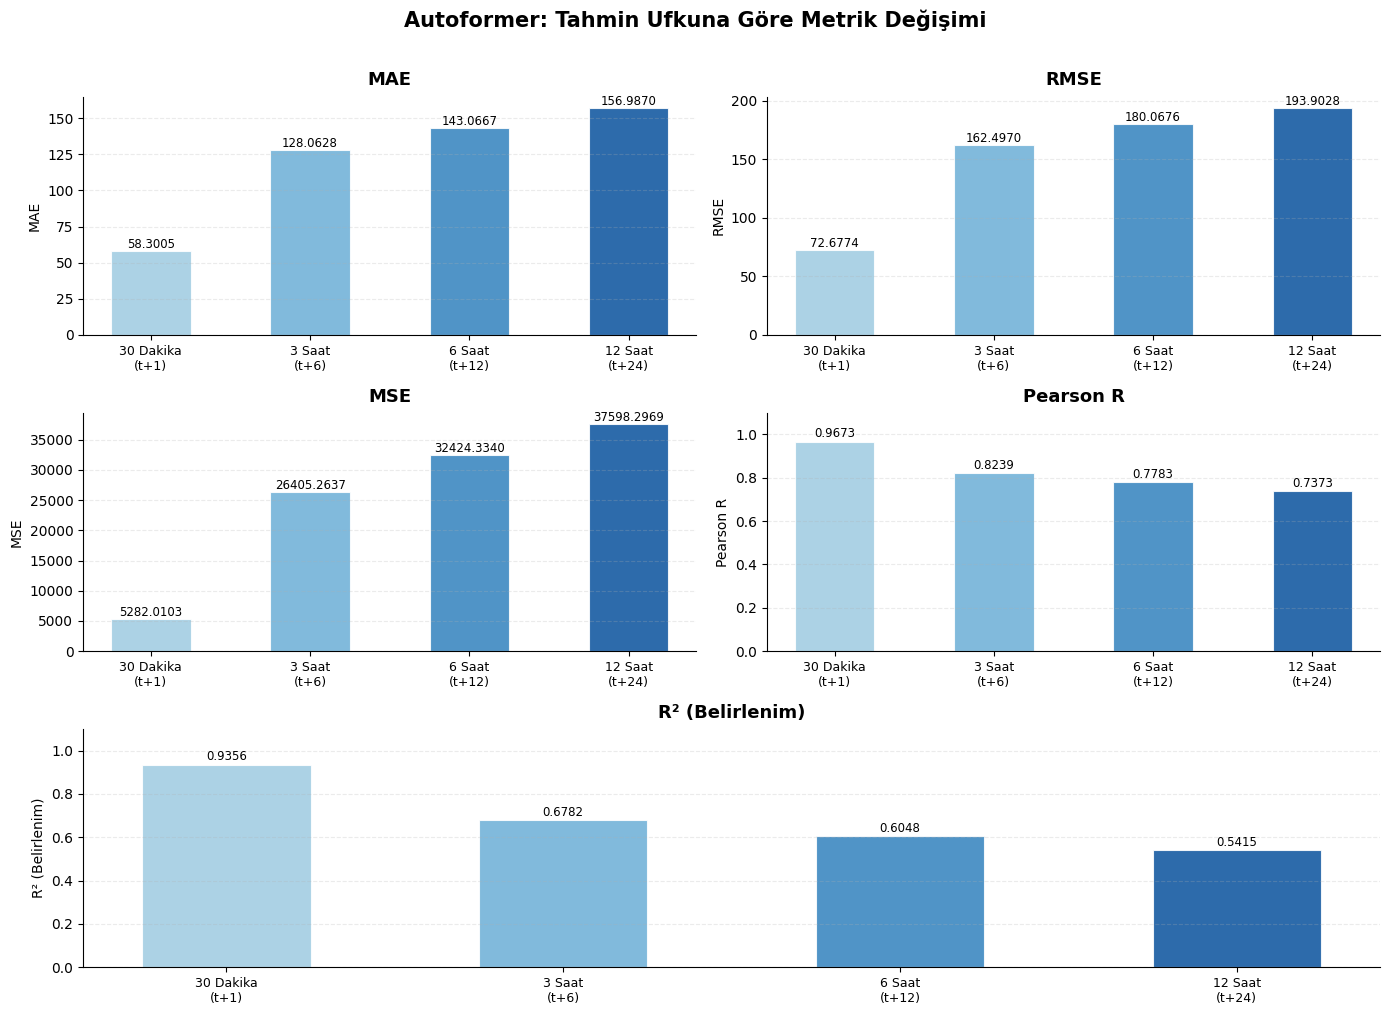

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

print("⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...\n")

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dakika\n(t+1)', '3 Saat\n(t+6)', '6 Saat\n(t+12)', '12 Saat\n(t+24)']

rmse_list, mae_list, mse_list, r2_list, r_list = [], [], [], [], []

for h in horizons:
    idx = h - 1
    true_h = all_trues[:, idx]
    pred_h = all_predictions[:, idx]

    rmse_list.append(np.sqrt(mean_squared_error(true_h, pred_h)))
    mae_list.append(mean_absolute_error(true_h, pred_h))
    mse_list.append(mean_squared_error(true_h, pred_h))
    r2_list.append(r2_score(true_h, pred_h))
    r_list.append(pearsonr(true_h, pred_h)[0])

    label = horizon_labels[horizons.index(h)].replace("\n", " ")
    print(f"Hedef: {label} -> RMSE: {rmse_list[-1]:.4f} | MAE: {mae_list[-1]:.4f} | "
          f"MSE: {mse_list[-1]:.4f} | R²: {r2_list[-1]:.4f} | r: {r_list[-1]:.4f}")

# ==========================================
#  Grafik — 5 panel, 2 sütun (son satır ortada)
# ==========================================
autoformer_palette = ['#9ecae1', '#6baed6', '#3182bd', '#08519c']

metrics = [
    ('MAE',       mae_list,  False),
    ('RMSE',      rmse_list, False),
    ('MSE',              mse_list,  False),
    ('Pearson R',        r_list,    True),
    ('R² (Belirlenim)',  r2_list,   True),
]

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Autoformer: Tahmin Ufkuna Göre Metrik Değişimi',
             fontsize=15, fontweight='bold', y=1.01)

x = np.arange(len(horizons))

for i, (name, values, bounded) in enumerate(metrics):
    if i < 4:
        ax = fig.add_subplot(3, 2, i + 1)
    else:
        ax = fig.add_subplot(3, 2, (5, 6))

    bars = ax.bar(x, values, color=autoformer_palette, alpha=0.85,
                  width=0.5, edgecolor='white', linewidth=0.8)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(horizon_labels, fontsize=9)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    if bounded:
        ax.set_ylim(0, 1.1)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='500')

fig.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_degradation.pdf', bbox_inches='tight', dpi=300)
plt.show()


📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...


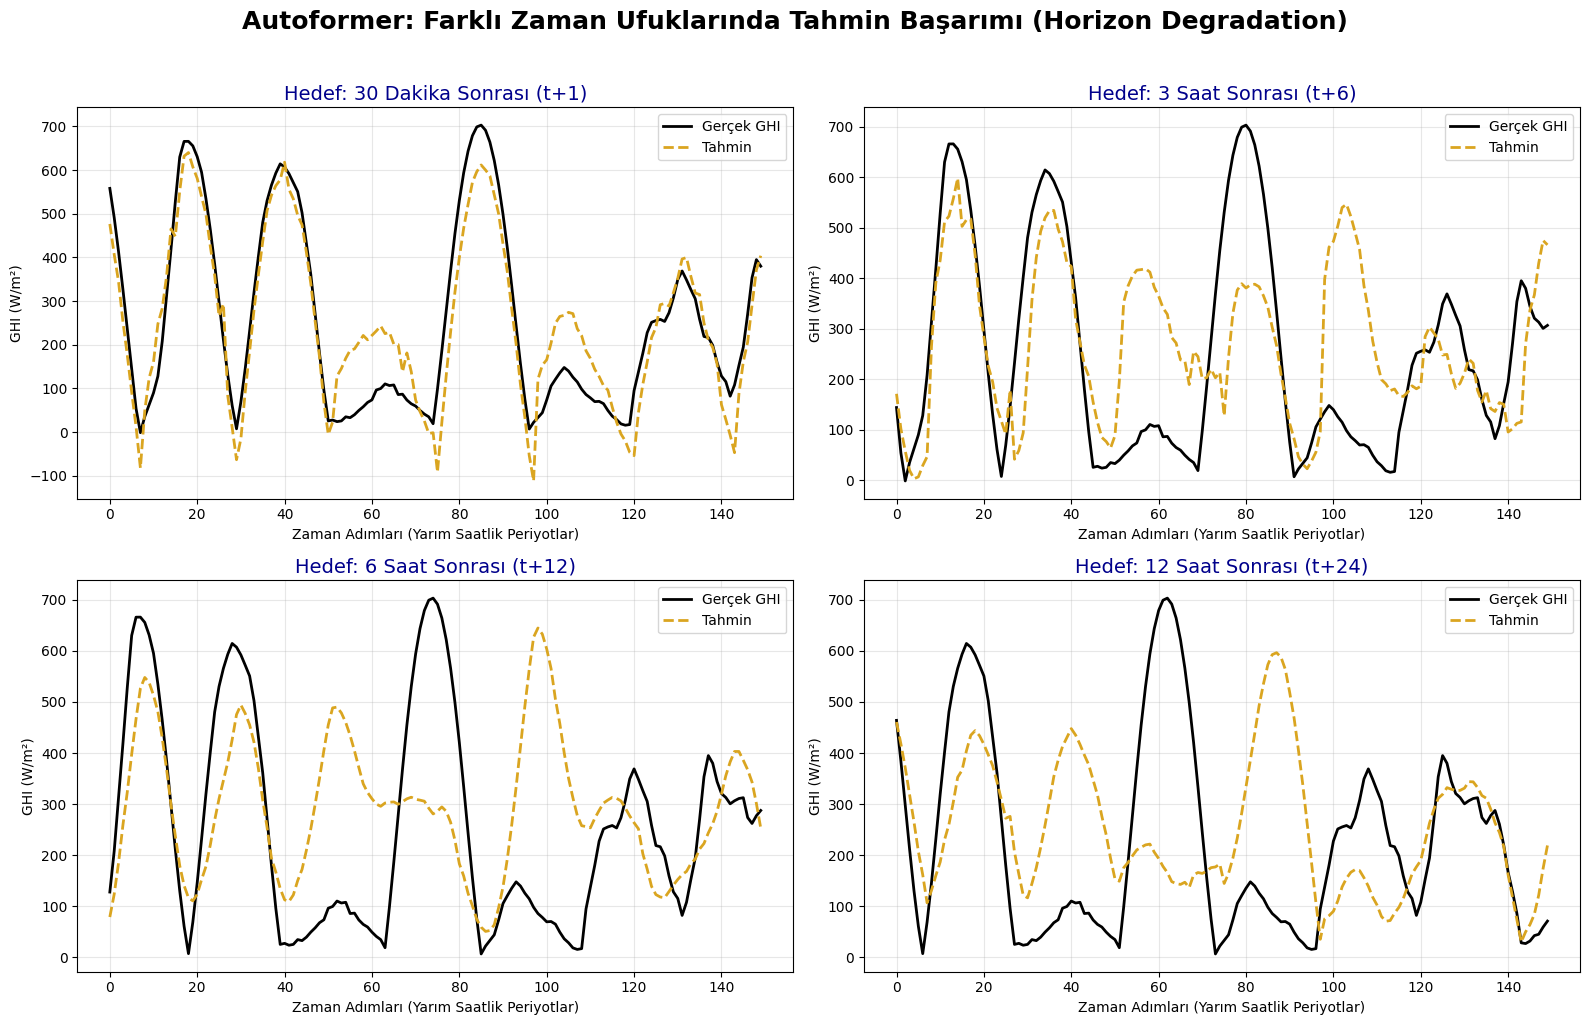

In [112]:
import matplotlib.pyplot as plt

print("📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...")

# İnceleyeceğimiz ufuklar ve indeksleri (Python'da indeks 0'dan başladığı için -1 yapıyoruz)
horizons_to_plot = [
    {"step": 1, "name": "30 Dakika Sonrası (t+1)", "idx": 0},
    {"step": 6, "name": "3 Saat Sonrası (t+6)", "idx": 5},
    {"step": 12, "name": "6 Saat Sonrası (t+12)", "idx": 11},
    {"step": 24, "name": "12 Saat Sonrası (t+24)", "idx": 23}
]

# Önceki grafikte kullandığımız aynı zaman aralığını alalım ki kıyaslama adil olsun
START_IDX = 1000
WINDOW_SIZE = 150

# 2x2'lik bir pano (subplot) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Autoformer: Farklı Zaman Ufuklarında Tahmin Başarımı (Horizon Degradation)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten() # 2x2'lik matrisi düz bir listeye çevir (Döngüde kolaylık için)

for i, h_info in enumerate(horizons_to_plot):
    ax = axes[i]
    idx = h_info["idx"]
    
    # Sadece o ufka (örneğin 3 saat sonrasına) ait tahminleri ve gerçekleri çek
    true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, idx]
    pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, idx]
    
    ax.plot(true_line, label='Gerçek GHI', color='black', linewidth=2)
    ax.plot(pred_line, label='Tahmin', color='#DAA520', linewidth=2, linestyle='--')
    
    ax.set_title(f"Hedef: {h_info['name']}", fontsize=14, color='darkblue')
    ax.set_xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=10)
    ax.set_ylabel('GHI (W/m²)', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_subplots.pdf', bbox_inches='tight')
plt.show()

🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...



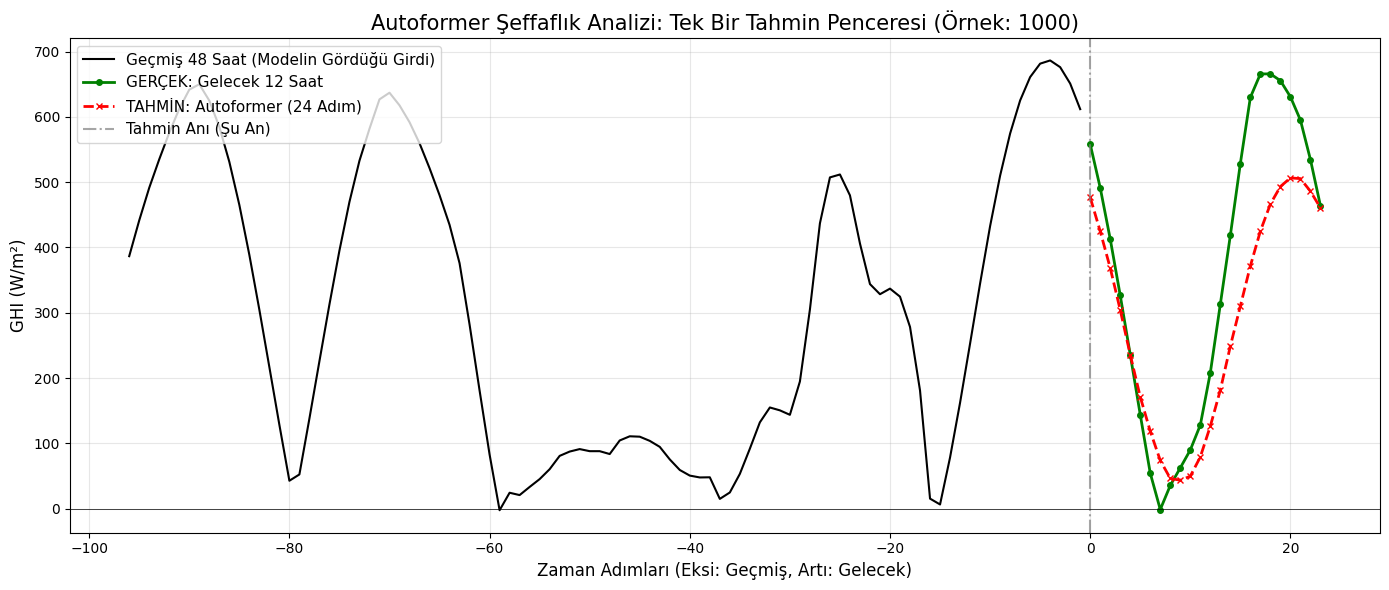

In [113]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...\n")

# Rastgele ama manidar bir zaman noktası seçelim (Örneğin test setinin 1000. adımı)
# İstersen bu rakamı 2000, 5000 yapıp farklı günlere de bakabilirsin.
SAMPLE_IDX = 1000

# 1. GEÇMİŞ: Modelin baktığı 96 adımlık geçmişi (X_test'ten) alıyoruz
# X_test boyutu (Örnek Sayısı, 96, 11). GHI_Filtered 0. indekste.
past_ghi = X_test[SAMPLE_IDX, :, 0] 

# 2. GELECEK: 24 adımlık gerçek değer ve modelin tahmini (all_trues ve all_predictions'dan)
true_future = all_trues[SAMPLE_IDX, :]
pred_future = all_predictions[SAMPLE_IDX, :]

# X ekseni (Zaman) ayarları: Geçmişi eksi (-), geleceği artı (+) olarak ayarlayalım
past_time = np.arange(-96, 0)
future_time = np.arange(0, 24)

# ==========================================
# 📊 GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(14, 6))

# Geçmişi çiz
plt.plot(past_time, past_ghi, label='Geçmiş 48 Saat (Modelin Gördüğü Girdi)', color='black', linewidth=1.5)

# Geleceği çiz (Gerçek vs Tahmin)
plt.plot(future_time, true_future, label='GERÇEK: Gelecek 12 Saat', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(future_time, pred_future, label='TAHMİN: Autoformer (24 Adım)', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

# Bugünü (0 noktasını) belirten dikey çizgi
plt.axvline(x=0, color='gray', linestyle='-.', alpha=0.7, label='Tahmin Anı (Şu An)')

plt.title(f'Autoformer Şeffaflık Analizi: Tek Bir Tahmin Penceresi (Örnek: {SAMPLE_IDX})', fontsize=15)
plt.xlabel('Zaman Adımları (Eksi: Geçmiş, Artı: Gelecek)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)

# X ekseni metinlerini düzenleyelim
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_single_window_forecast.pdf')
plt.show()

# PATCHTST Grafikleri

Model eğitimi için cihaz: MPS
1. Model Yükleniyor...
1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...
2. Metrikler Hesaplanıyor...

 TEST SETİ KARNESİ PatchTST (2024)
---------------------------------
RMSE (Kök Ortalama Kare Hata) : 128.74395465176218 
MAE  (Ortalama Mutlak Hata)   : 90.65835571289062 
MSE  (Ortalama Kare Hata)     : 16575.005859375 

3. Örnek Bir Zaman Dilimi Çizdiriliyor...


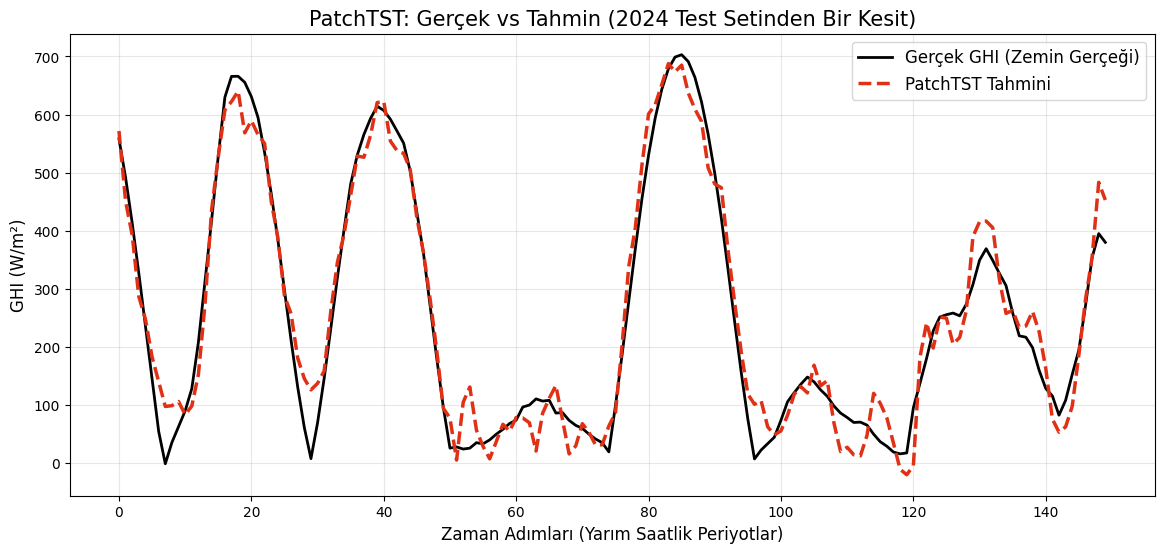

In [114]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")

from src.models.patchtst import CustomPatchTST

print("1. Model Yükleniyor...")
# Boş modeli oluştur
model_patch = CustomPatchTST(seq_len=96, pred_len=24, enc_in=11).to(device)
# State dictionary'yi yükle
model_patch.load_state_dict(torch.load('../outputs/models/patchtst_solar_model.pth'))

print("1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...")
model_patch.eval() # Modeli sınav moduna al (dropout vs kapatılır)

all_predictions = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Tahmin yap
        outputs = model_patch(batch_X)
        
        # CPU'ya çek ve numpy array'e çevir
        all_predictions.append(outputs.cpu().numpy())
        all_trues.append(batch_y.cpu().numpy())

# Bütün batch'leri tek bir uzun listeye birleştir
all_predictions = np.concatenate(all_predictions, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print("2. Metrikler Hesaplanıyor...")
# Sadece ilk tahmin adımını (t+1) değil, tüm 24 adımlık (12 saat) ufku değerlendiriyoruz
mse = mean_squared_error(all_trues, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_trues, all_predictions)

print(f"\n TEST SETİ KARNESİ PatchTST (2024)")
print(f"---------------------------------")
print(f"RMSE (Kök Ortalama Kare Hata) : {rmse} ")
print(f"MAE  (Ortalama Mutlak Hata)   : {mae} ")
print(f"MSE  (Ortalama Kare Hata)     : {mse} ")

# ==========================================
# 3. GÖRSELLEŞTİRME (Gerçek Hava vs Model)
# ==========================================
print("\n3. Örnek Bir Zaman Dilimi Çizdiriliyor...")

START_IDX = 1000
WINDOW_SIZE = 150

# Tahminlerin sadece ilk ufuk adımını (t+1) alarak sürekli bir çizgi oluşturalım
true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, 0]
pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, 0]

plt.figure(figsize=(14, 6))
plt.plot(true_line, label='Gerçek GHI (Zemin Gerçeği)', color='black', linewidth=2)
plt.plot(pred_line, label='PatchTST Tahmini', color="#E03116", linewidth=2.5, linestyle='--')

plt.title('PatchTST: Gerçek vs Tahmin (2024 Test Setinden Bir Kesit)', fontsize=15)
plt.xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Çıktıyı kaydet
plt.savefig('../outputs/plots/patchtst_test_predictions.pdf', bbox_inches='tight')
plt.show()


⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...

Hedef: 30 Dakika (t+1) -> RMSE: 56.5640 | MAE: 41.4072 | MSE: 3199.4844 | R²: 0.9610 | r: 0.9807
Hedef: 3 Saat (t+6) -> RMSE: 112.8764 | MAE: 79.4207 | MSE: 12741.0820 | R²: 0.8447 | r: 0.9193
Hedef: 6 Saat (t+12) -> RMSE: 136.5527 | MAE: 97.8621 | MSE: 18646.6289 | R²: 0.7727 | r: 0.8795
Hedef: 12 Saat (t+24) -> RMSE: 148.2578 | MAE: 108.3379 | MSE: 21980.3848 | R²: 0.7319 | r: 0.8560


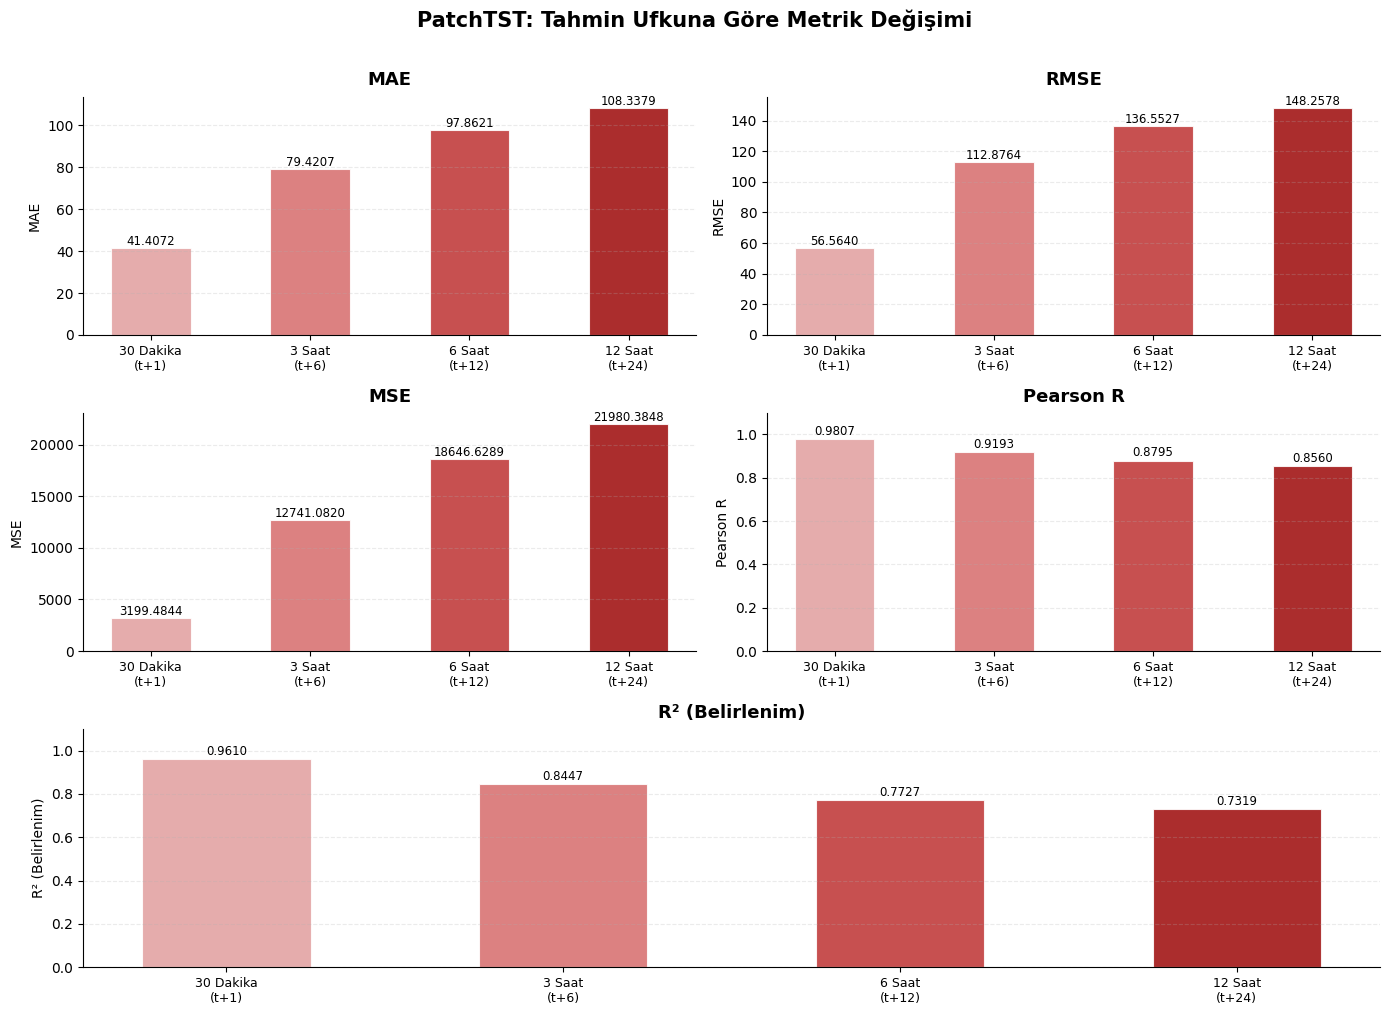

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

print("⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...\n")

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dakika\n(t+1)', '3 Saat\n(t+6)', '6 Saat\n(t+12)', '12 Saat\n(t+24)']

rmse_list, mae_list, mse_list, r2_list, r_list = [], [], [], [], []

for h in horizons:
    idx = h - 1
    true_h = all_trues[:, idx]
    pred_h = all_predictions[:, idx]

    rmse_list.append(np.sqrt(mean_squared_error(true_h, pred_h)))
    mae_list.append(mean_absolute_error(true_h, pred_h))
    mse_list.append(mean_squared_error(true_h, pred_h))
    r2_list.append(r2_score(true_h, pred_h))
    r_list.append(pearsonr(true_h, pred_h)[0])  # ← döngü içinde append

    label = horizon_labels[horizons.index(h)].replace("\n", " ")
    print(f"Hedef: {label} -> RMSE: {rmse_list[-1]:.4f} | MAE: {mae_list[-1]:.4f} | "
          f"MSE: {mse_list[-1]:.4f} | R²: {r2_list[-1]:.4f} | r: {r_list[-1]:.4f}")

# ==========================================
# 📊 GRAFİK — 5 panel, 2 sütun (son satır ortada)
# ==========================================
patchtst_palette = ["#e19e9e", "#d66b6b", "#bd3131", "#9c0808"]

metrics = [
    ('MAE',       mae_list,  False),
    ('RMSE',      rmse_list, False),
    ('MSE',              mse_list,  False),
    ('Pearson R',        r_list,    True),
    ('R² (Belirlenim)',  r2_list,   True),
]

fig = plt.figure(figsize=(14, 10))
fig.suptitle('PatchTST: Tahmin Ufkuna Göre Metrik Değişimi',
             fontsize=15, fontweight='bold', y=1.01)

x = np.arange(len(horizons))

for i, (name, values, bounded) in enumerate(metrics):
    if i < 4:
        ax = fig.add_subplot(3, 2, i + 1)
    else:
        ax = fig.add_subplot(3, 2, (5, 6))

    bars = ax.bar(x, values, color=patchtst_palette, alpha=0.85,
                  width=0.5, edgecolor='white', linewidth=0.8)

    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(horizon_labels, fontsize=9)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    if bounded:
        ax.set_ylim(0, 1.1)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='500')

fig.tight_layout()
plt.savefig('../outputs/plots/patchtst_horizon_degradation.pdf', bbox_inches='tight', dpi=300)
plt.show()


📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...


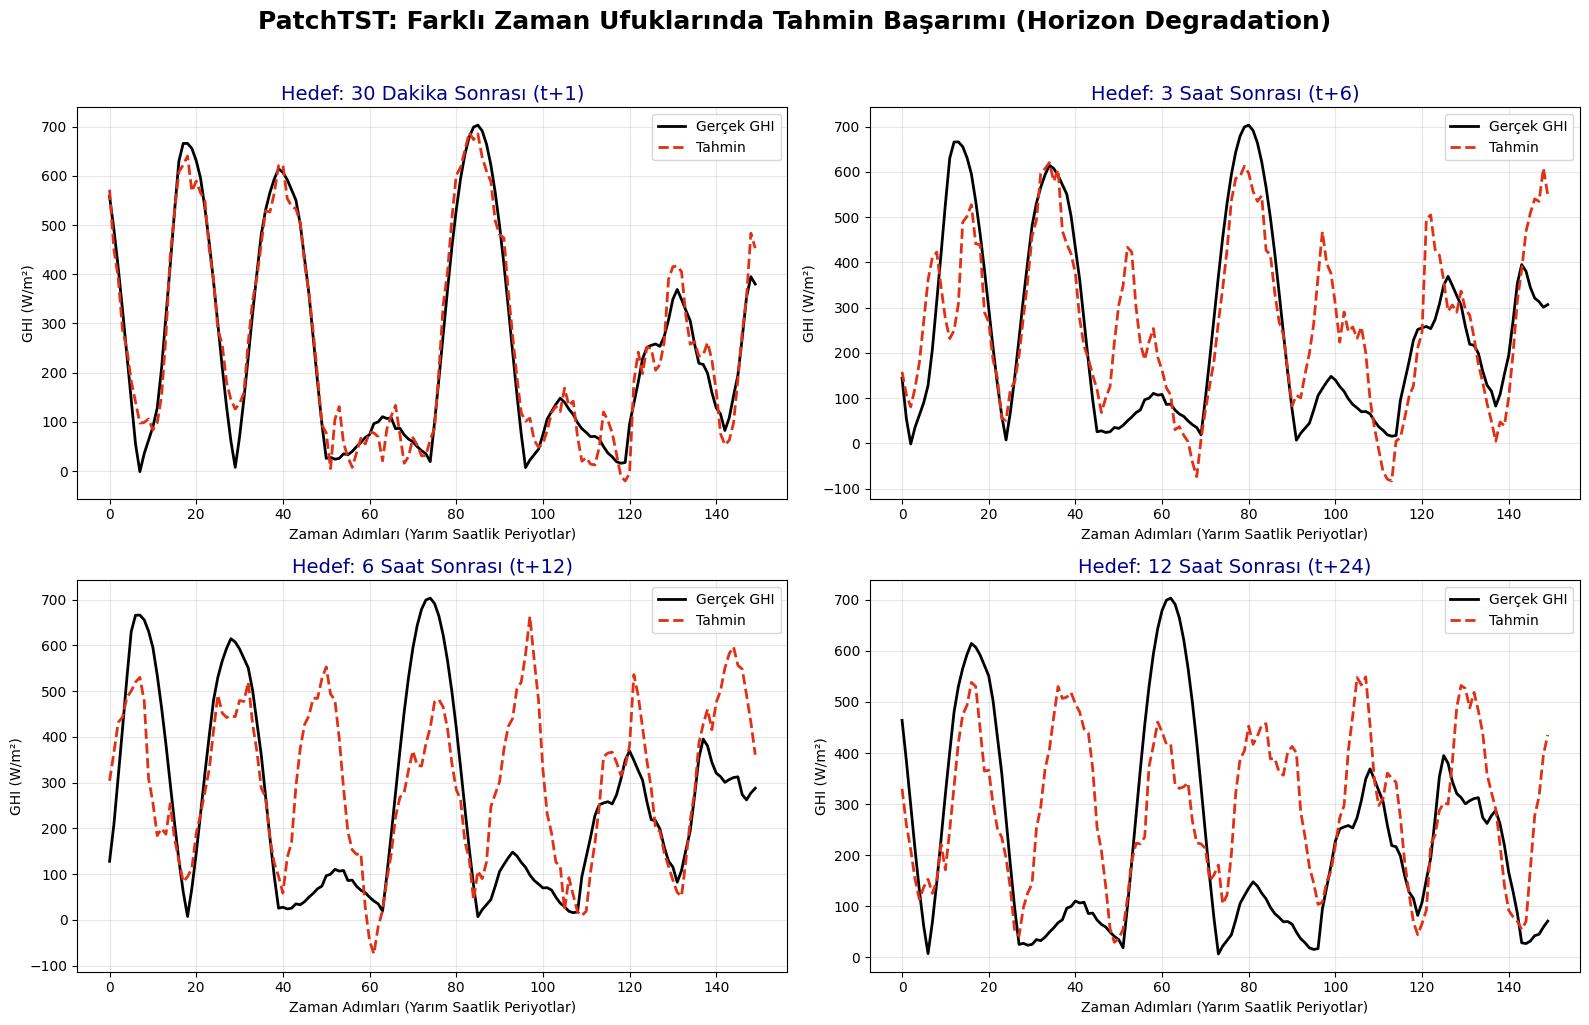

In [116]:
import matplotlib.pyplot as plt

print("📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...")

# İnceleyeceğimiz ufuklar ve indeksleri (Python'da indeks 0'dan başladığı için -1 yapıyoruz)
horizons_to_plot = [
    {"step": 1, "name": "30 Dakika Sonrası (t+1)", "idx": 0},
    {"step": 6, "name": "3 Saat Sonrası (t+6)", "idx": 5},
    {"step": 12, "name": "6 Saat Sonrası (t+12)", "idx": 11},
    {"step": 24, "name": "12 Saat Sonrası (t+24)", "idx": 23}
]

# Önceki grafikte kullandığımız aynı zaman aralığını alalım ki kıyaslama adil olsun
START_IDX = 1000
WINDOW_SIZE = 150

# 2x2'lik bir pano (subplot) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PatchTST: Farklı Zaman Ufuklarında Tahmin Başarımı (Horizon Degradation)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten() # 2x2'lik matrisi düz bir listeye çevir (Döngüde kolaylık için)

for i, h_info in enumerate(horizons_to_plot):
    ax = axes[i]
    idx = h_info["idx"]
    
    # Sadece o ufka (örneğin 3 saat sonrasına) ait tahminleri ve gerçekleri çek
    true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, idx]
    pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, idx]
    
    ax.plot(true_line, label='Gerçek GHI', color='black', linewidth=2)
    ax.plot(pred_line, label='Tahmin', color="#E03116", linewidth=2, linestyle='--')
    
    ax.set_title(f"Hedef: {h_info['name']}", fontsize=14, color='darkblue')
    ax.set_xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=10)
    ax.set_ylabel('GHI (W/m²)', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/patchtst_horizon_subplots.pdf', bbox_inches='tight')
plt.show()

🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...



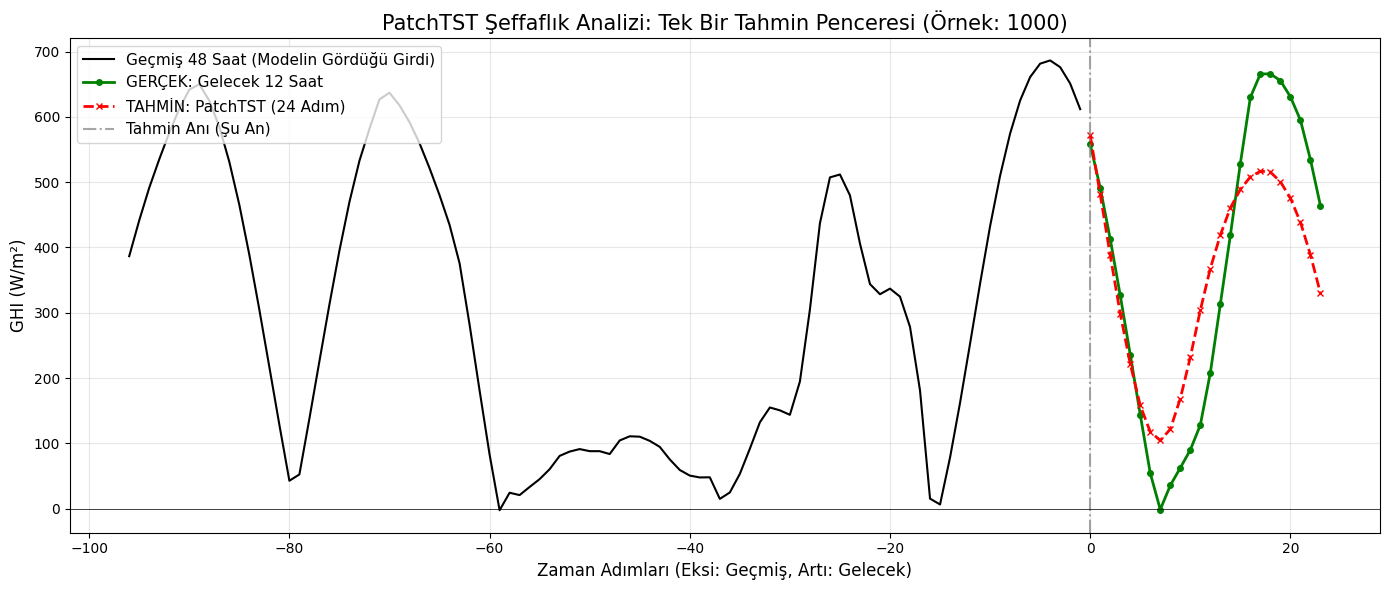

In [117]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...\n")

# Rastgele ama manidar bir zaman noktası seçelim (Örneğin test setinin 1000. adımı)
# İstersen bu rakamı 2000, 5000 yapıp farklı günlere de bakabilirsin.
SAMPLE_IDX = 1000

# 1. GEÇMİŞ: Modelin baktığı 96 adımlık geçmişi (X_test'ten) alıyoruz
# X_test boyutu (Örnek Sayısı, 96, 11). GHI_Filtered 0. indekste.
past_ghi = X_test[SAMPLE_IDX, :, 0] 

# 2. GELECEK: 24 adımlık gerçek değer ve modelin tahmini (all_trues ve all_predictions'dan)
true_future = all_trues[SAMPLE_IDX, :]
pred_future = all_predictions[SAMPLE_IDX, :]

# X ekseni (Zaman) ayarları: Geçmişi eksi (-), geleceği artı (+) olarak ayarlayalım
past_time = np.arange(-96, 0)
future_time = np.arange(0, 24)

# ==========================================
# 📊 GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(14, 6))

# Geçmişi çiz
plt.plot(past_time, past_ghi, label='Geçmiş 48 Saat (Modelin Gördüğü Girdi)', color='black', linewidth=1.5)

# Geleceği çiz (Gerçek vs Tahmin)
plt.plot(future_time, true_future, label='GERÇEK: Gelecek 12 Saat', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(future_time, pred_future, label='TAHMİN: PatchTST (24 Adım)', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

# Bugünü (0 noktasını) belirten dikey çizgi
plt.axvline(x=0, color='gray', linestyle='-.', alpha=0.7, label='Tahmin Anı (Şu An)')

plt.title(f'PatchTST Şeffaflık Analizi: Tek Bir Tahmin Penceresi (Örnek: {SAMPLE_IDX})', fontsize=15)
plt.xlabel('Zaman Adımları (Eksi: Geçmiş, Artı: Gelecek)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)

# X ekseni metinlerini düzenleyelim
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/patchtst_single_window_forecast.pdf')
plt.show()

Metrik     | Autoformer      | PatchTST       
---------------------------------------------
MSE        | 29559.8906      | 16575.0059     
RMSE       | 171.9299        | 128.7440       
MAE        | 134.7306        | 90.6584        
R2         | 0.6397          | 0.7979         
R          | 0.8001          | 0.8935         


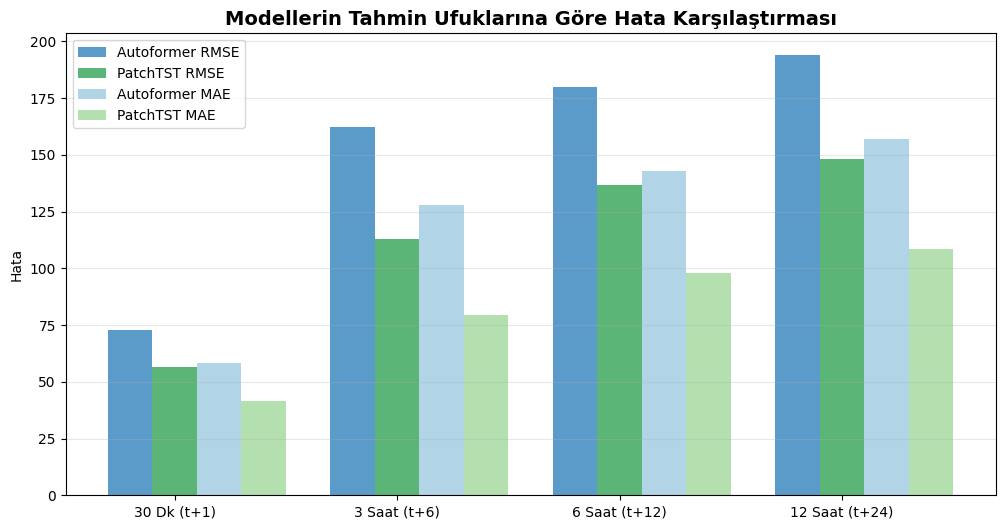

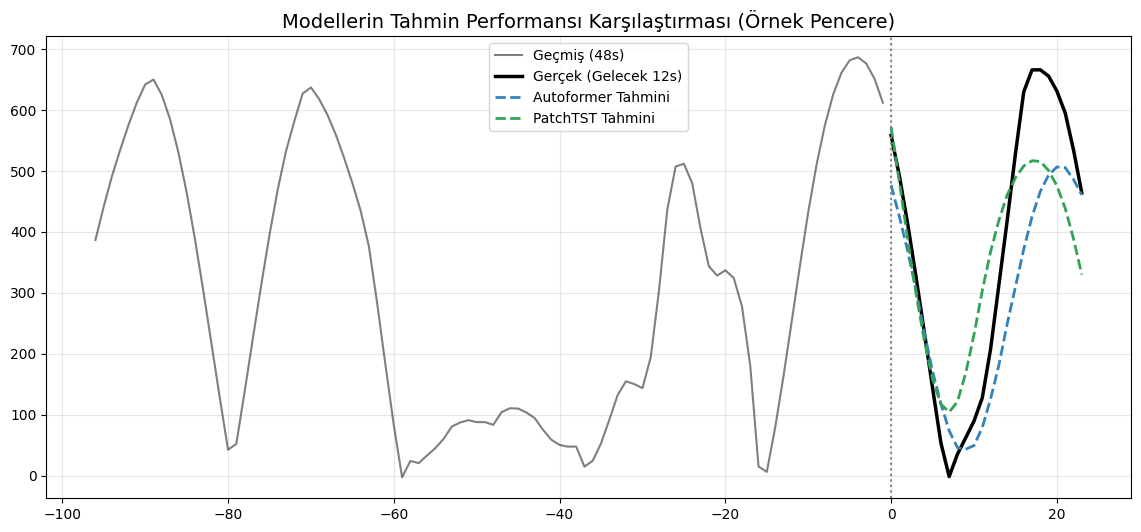

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Metrikleri Tek Bir Tabloda Özetleyelim
true_inputs = []
autoformer_preds = []
patchtst_preds = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Tahminleri al
        pred_auto = model_autoformer(batch_X)
        pred_patch = model_patch(batch_X)
        
        # CPU'ya çekip kaydedelim
        true_inputs.append(batch_y.cpu().numpy())
        autoformer_preds.append(pred_auto.cpu().numpy())
        patchtst_preds.append(pred_patch.cpu().numpy())

# Tüm batch'leri birleştiriyoruz (Şekil: Örnek Sayısı, 24)
all_trues = np.concatenate(true_inputs, axis=0)
all_preds_auto = np.concatenate(autoformer_preds, axis=0)
all_preds_patch = np.concatenate(patchtst_preds, axis=0)


def calculate_global_metrics(trues, preds):
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues, preds)
    r2 = r2_score(trues, preds)
    # Pearson R için matrisleri tek boyuta düzleştiriyoruz
    r_coeff, _ = pearsonr(trues.flatten(), preds.flatten())
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "R": r_coeff}

auto_metrics = calculate_global_metrics(all_trues, all_preds_auto)
patch_metrics = calculate_global_metrics(all_trues, all_preds_patch)


print(f"{'Metrik':<10} | {'Autoformer':<15} | {'PatchTST':<15}")
print("-" * 45)
for m in ["MSE", "RMSE", "MAE", "R2", "R"]:
    print(f"{m:<10} | {auto_metrics[m]:<15.4f} | {patch_metrics[m]:<15.4f}")

# 2. Grafik: İki Modelin Horizon Degradation Karşılaştırması
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.2
indices = np.arange(len(horizons))

horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dk (t+1)', '3 Saat (t+6)', '6 Saat (t+12)', '12 Saat (t+24)']

auto_rmse_h, auto_mae_h = [], []
patch_rmse_h, patch_mae_h = [], []

for h in horizons:
    idx = h - 1
    # Autoformer adım metrikleri
    auto_rmse_h.append(np.sqrt(mean_squared_error(all_trues[:, idx], all_preds_auto[:, idx])))
    auto_mae_h.append(mean_absolute_error(all_trues[:, idx], all_preds_auto[:, idx]))
    # PatchTST adım metrikleri
    patch_rmse_h.append(np.sqrt(mean_squared_error(all_trues[:, idx], all_preds_patch[:, idx])))
    patch_mae_h.append(mean_absolute_error(all_trues[:, idx], all_preds_patch[:, idx]))

# Autoformer (Mavi tonları) ve PatchTST (Yeşil tonları)
ax.bar(indices - bar_width, auto_rmse_h, width=bar_width, label='Autoformer RMSE', color='#3182bd', alpha=0.8)
ax.bar(indices, patch_rmse_h, width=bar_width, label='PatchTST RMSE', color='#31a354', alpha=0.8)
ax.bar(indices + bar_width, auto_mae_h, width=bar_width, label='Autoformer MAE', color='#9ecae1', alpha=0.8)
ax.bar(indices + 2*bar_width, patch_mae_h, width=bar_width, label='PatchTST MAE', color='#a1d99b', alpha=0.8)

ax.set_title('Modellerin Tahmin Ufuklarına Göre Hata Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(indices)
ax.set_xticklabels(horizon_labels)
ax.set_ylabel('Hata')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.savefig('../outputs/plots/comparison_metrics.pdf', bbox_inches='tight')
plt.show()

# 3. Grafik: PatchTST vs Autoformer Single Window (Örnekleme)
SAMPLE_IDX = 1000
plt.figure(figsize=(14, 6))
plt.plot(past_time, past_ghi, label='Geçmiş (48s)', color='black', alpha=0.5)
plt.plot(future_time, all_trues[SAMPLE_IDX, :], label='Gerçek (Gelecek 12s)', color='black', linewidth=2.5)
plt.plot(future_time, all_preds_auto[SAMPLE_IDX, :], label='Autoformer Tahmini', color='#3182bd', linestyle='--', linewidth=2)
plt.plot(future_time, all_preds_patch[SAMPLE_IDX, :], label='PatchTST Tahmini', color='#31a354', linestyle='--', linewidth=2)
plt.axvline(x=0, color='gray', linestyle=':')
plt.title('Modellerin Tahmin Performansı Karşılaştırması (Örnek Pencere)', fontsize=14)
plt.legend()
plt.savefig('../outputs/plots/comparison_single_window.pdf', bbox_inches='tight')
plt.grid(alpha=0.3)
plt.show()